# Dataset statistics

Count and group-by queries with matplotlib charts. Use this
notebook to get a feel for how the corpus is distributed across
agent types, ego actions, and environments before you go
looking for specific scenarios.

> See `01_quickstart.ipynb` for an introduction to the dataset
> and `02_query_dsl_tour.ipynb` for the query language itself.


## Setup


In [1]:
import os
from collections import Counter
from pathlib import Path

from cascade_av.dataset import CascadeDataset

# --- shared notebook styling -----------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "figure.dpi": 110,
    "savefig.dpi": 110,
})

pd.options.display.max_colwidth = 110
pd.options.display.width = 140
pd.options.display.float_format = "{:.2f}".format


In [2]:
ds = CascadeDataset(Path(os.environ["CASCADE_AV_DATASET_ROOT"]))
print(f"corpus loaded — {len(ds)} clips")

def entity_count(query: str) -> int:
    """Number of matching *entities* across the corpus (not clips)."""
    return len(ds.find(query).matches)

def entities_by_attr(query: str, attr: str) -> dict:
    """Bucket matching entities by a top-level attribute (e.g. ``type``).

    Like ``ds.group_by`` but counts entities rather than clips.
    """
    out = Counter()
    for m in ds.find(query).matches:
        val = getattr(m.entity, attr, None)
        if isinstance(val, list):
            for v in val:
                out[v] += 1
        else:
            out[val] += 1
    return dict(out)


corpus loaded — 344 clips


/home/horde/Projects/av-causal-dataset-tools-feat-dsl-attribute-surface/src/cascade_av/dataset.py:118: UserWarning: 1 clip_id(s) had multiple annotation files; kept first by filename. (Set CASCADE_AV_VERBOSE=1 for per-file detail.)
  self._scan(annotation_paths, annotation_root)


## Clips vs entities

The query API exposes two complementary perspectives:

- **`ds.count(query)`** — the number of *clips* with ≥1 match.
  Tells you about *coverage*: "how many clips even contain
  this thing?"
- **`len(ds.find(query).matches)`** — the number of *matching
  entities*. Tells you about *prevalence*: "how often does
  this thing occur?" A single clip can contribute many
  entities (six pedestrians, four vehicles, …).

Both are useful — coverage tells you how varied the corpus
is; prevalence tells you the actual instance counts.


## Headline counts


In [3]:
primitives = [
    ("pedestrian",              "agent.type = ped"),
    ("vehicle",                 "agent.type = vehicle"),
    ("VRU (ped/cyclist)",       "agent.type = vru"),
    ("cyclist",                 "agent.type = cyclist"),
    ("stop sign",               "obj.type = stop_sign"),
    ("yield sign",              "obj.type = yield_sign"),
    ("crosswalk environment",   "env.type = crosswalk"),
    ("intersection environment", "env.type = intersection"),
    ("roundabout environment",  "env.type = roundabout"),
]
headline = pd.DataFrame(
    [(label, ds.count(q), entity_count(q)) for label, q in primitives],
    columns=["category", "clips", "entities"],
).sort_values("entities", ascending=False, ignore_index=True)
headline


,category,clips,entities
0,vehicle,313,1028
1,VRU (ped/cyclist),144,347
2,crosswalk environment,176,336
3,pedestrian,133,296
4,intersection environment,210,287
5,stop sign,51,63
6,yield sign,38,53
7,cyclist,34,51
8,roundabout environment,28,29


## Distribution of agent types

`group_by(query, key)` buckets matches by the value of `key`
and returns **clip counts**. Pair it with
`entities_by_attr(query, attr)` to see entity counts in the
same buckets.


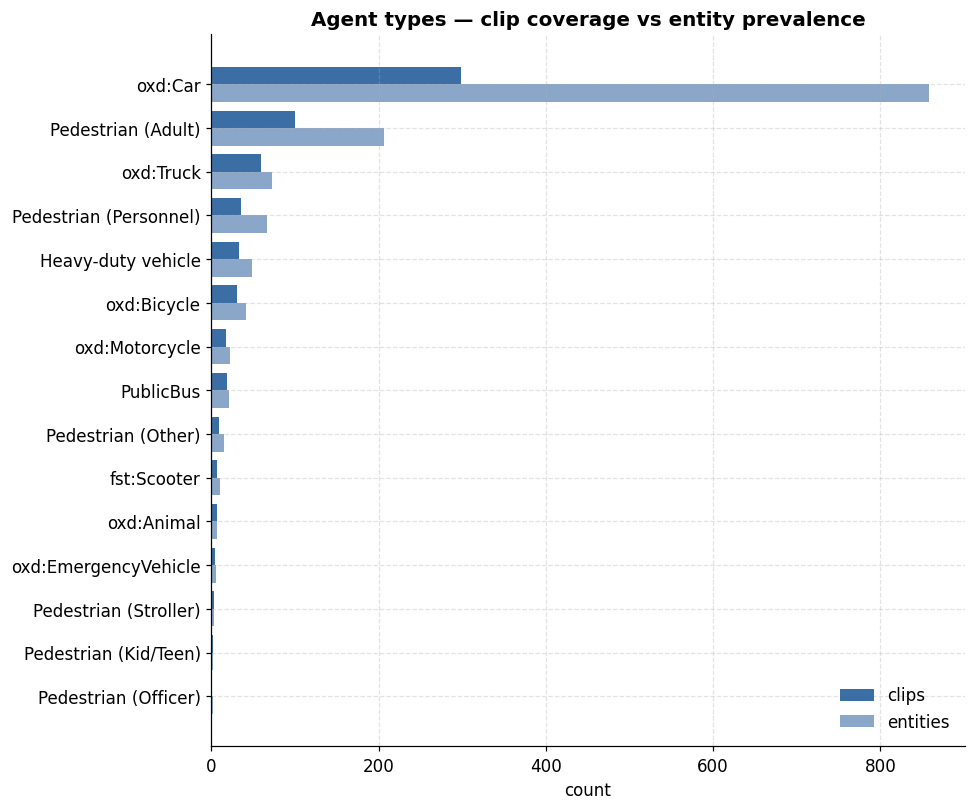

,clips,entities
Pedestrian (Officer),1,2
Pedestrian (Kid/Teen),2,2
Pedestrian (Stroller),3,3
oxd:EmergencyVehicle,4,5
oxd:Animal,7,7
fst:Scooter,7,10
Pedestrian (Other),9,15
PublicBus,19,21
oxd:Motorcycle,18,22
oxd:Bicycle,31,41


In [4]:
agent_query = "agent.type = vehicle or agent.type = vru or agent.type = animal"

clips_by_type    = ds.group_by(agent_query, key="agent.type")
entities_by_type = entities_by_attr(agent_query, attr="type")

agent_df = pd.DataFrame({
    "clips":    pd.Series(clips_by_type),
    "entities": pd.Series(entities_by_type),
}).fillna(0).astype(int)
agent_df = agent_df.sort_values("entities", ascending=True)

fig, ax = plt.subplots(figsize=(9, 0.4 * len(agent_df) + 1.5))
y = range(len(agent_df))
ax.barh([i + 0.2 for i in y], agent_df["clips"],    height=0.4,
        color="#3b6ea5", label="clips")
ax.barh([i - 0.2 for i in y], agent_df["entities"], height=0.4,
        color="#8aa6c8", label="entities")
ax.set_yticks(list(y))
ax.set_yticklabels(agent_df.index)
ax.set_xlabel("count")
ax.set_title("Agent types — clip coverage vs entity prevalence")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

agent_df


## Distribution of ego actions


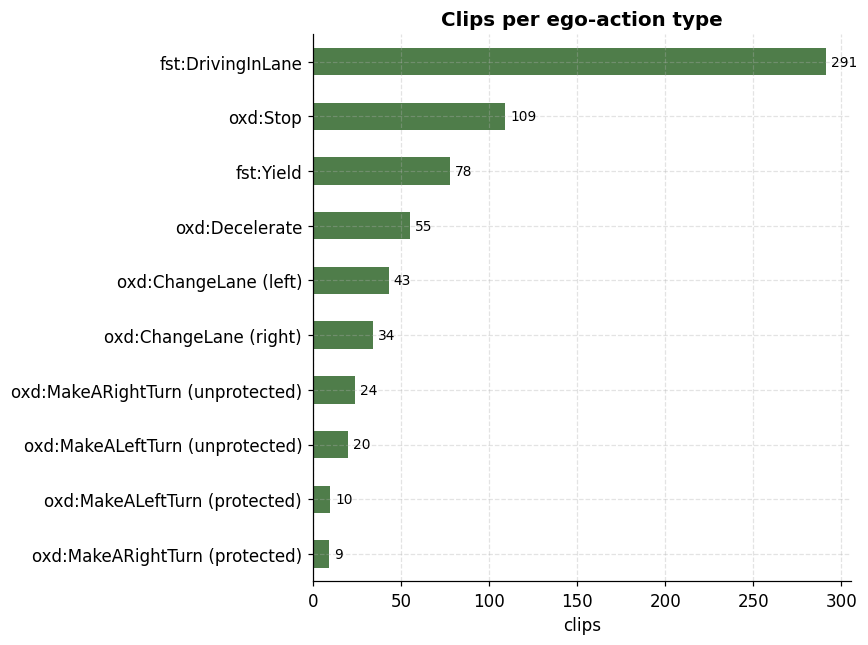

In [5]:
ego_dist = ds.group_by(
    "ego.action.type = drive or ego.action.type = stop or ego.action.type = decel "
    "or ego.action.type = yield or ego.action.type = turn_left "
    "or ego.action.type = turn_right or ego.action.type = change_lane",
    key="ego.action.type",
)
s = pd.Series(ego_dist, name="clips").sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 0.45 * max(len(s), 4) + 1.5))
s.plot(kind="barh", ax=ax, color="#4f7d4a")
ax.set_xlabel("clips")
ax.set_ylabel("")
ax.set_title("Clips per ego-action type")
for i, v in enumerate(s.values):
    ax.text(v + max(s.values) * 0.01, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()


## Distribution of environment types


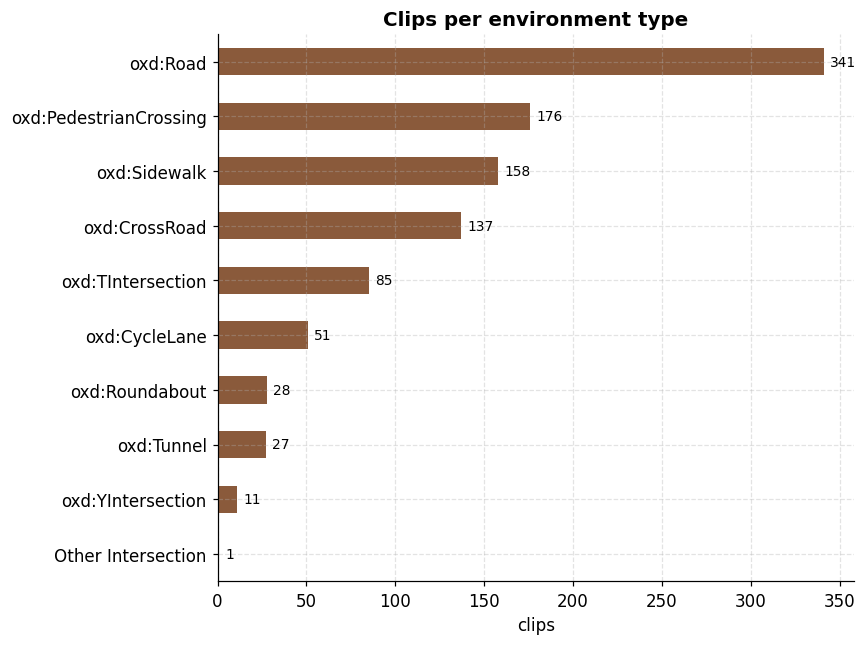

In [6]:
env_dist = ds.group_by(
    "env.type = road or env.type = intersection or env.type = crosswalk "
    "or env.type = sidewalk or env.type = roundabout or env.type = cycle_lane "
    "or env.type = tunnel",
    key="env.type",
)
s = pd.Series(env_dist, name="clips").sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 0.45 * max(len(s), 4) + 1.5))
s.plot(kind="barh", ax=ax, color="#8a5a3b")
ax.set_xlabel("clips")
ax.set_ylabel("")
ax.set_title("Clips per environment type")
for i, v in enumerate(s.values):
    ax.text(v + max(s.values) * 0.01, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()


## Composite questions

DSL queries compose, so you can pose questions that combine
primitives — for example, "of the clips that contain a red
light, what fraction also contain an ego stop?"


In [7]:
n_red               = ds.count("light.color = red")
n_red_stop          = ds.count("light.color = red and ego.action = stop")
n_yellow_clear      = ds.count("light(color = yellow, could_have_cleared = true)")
_jaywalk_q = (
    'agent(type = ped, action.type in ('
    '"oxd:Walk (jaywalk)", "oxd:Walk (jaywalk, erratic)", '
    '"oxd:Run (jaywalk)", "oxd:Run (jaywalk, erratic)"))'
)
n_jaywalk_clips     = ds.count(_jaywalk_q)
n_jaywalk_entities  = entity_count(_jaywalk_q)

composite = pd.DataFrame([
    ("ego stops at red light",            n_red_stop,         n_red, n_red_stop / max(n_red, 1)),
    ("yellow ego could have cleared",     n_yellow_clear,     None,  None),
    ("jaywalking pedestrian (clips)",     n_jaywalk_clips,    None,  None),
    ("jaywalking pedestrian (entities)",  n_jaywalk_entities, None,  None),
], columns=["question", "matching clips/entities", "denominator", "ratio"])
composite.style.format({"ratio": "{:.0%}"}, na_rep="—")


,question,matching clips/entities,denominator,ratio
0,ego stops at red light,52,97.000000,54%
1,yellow ego could have cleared,3,—,—
2,jaywalking pedestrian (clips),35,—,—
3,jaywalking pedestrian (entities),54,—,—
